In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

Training and Evaluating Model

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        88
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        19
           5       1.00      1.00      1.00        86
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00         7
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00       136
          10       1.00      1.00      1.00         9
          11       1.00      1.00      1.00         5

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



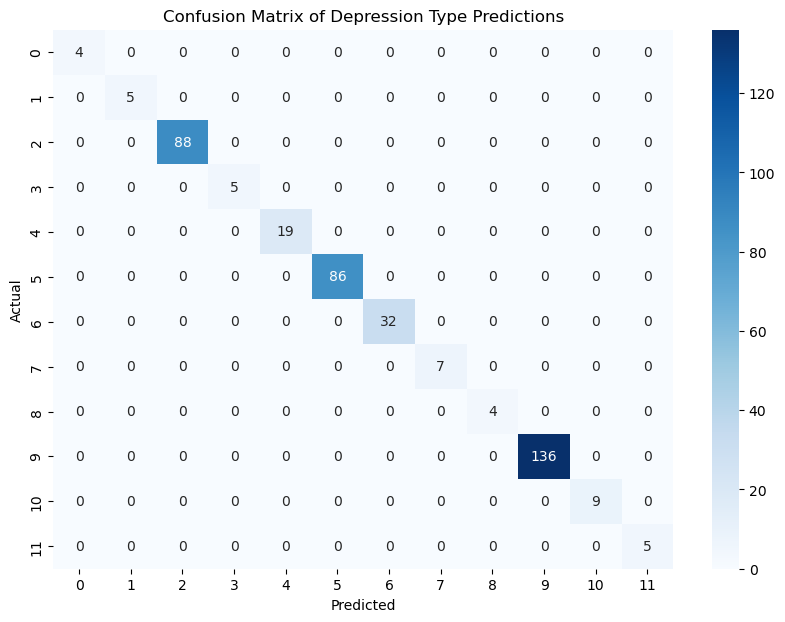

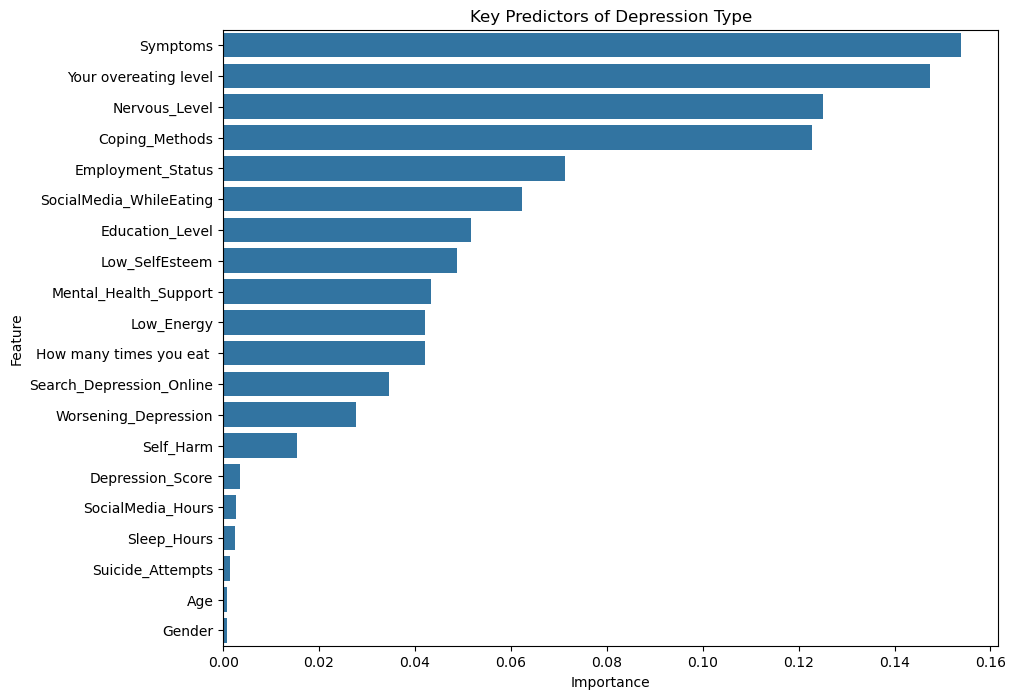

In [4]:
# 1. Load the dataset
# Ensure the CSV file is in the same directory as your notebook
df = pd.read_csv('Mental Health Classification.csv')

# 2. Preprocessing
# Define features (X) and target (y)
# We drop 'Depression_Type' because it is the target we want to predict
X = df.drop('Depression_Type', axis=1)
y = df['Depression_Type']

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
# Initialize the Random Forest Classifier
# n_estimators=100 means we are using 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# 4. Model Evaluation
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print the performance report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Depression Type Predictions')
plt.show()

# 5. Feature Importance Analysis
# Check which features (inputs) influenced the prediction most
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize Feature Importance
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Key Predictors of Depression Type')
plt.show()

Prediction Model

In [12]:
# Function to predict depression type based on user input
def predict_depression_type(user_input_data):
    # Convert input list to a DataFrame with correct column names
    input_df = pd.DataFrame([user_input_data], columns=X.columns)
    
    # Make prediction
    prediction_code = rf_model.predict(input_df)[0]
    
    # Mapping the numeric result to a readable name
    result_map = {
        0: "No clinically significant depression",
        1: "Minimal / Mild depression",
        2: "Moderate depression",
        3: "Moderately-severe depression",
        4: "Severe depression",
        5: "Persistent depressive disorder (Dysthymia)",
        6: "Seasonal affective pattern",
        7: "Peripartum / Postpartum depression",
        8: "Bipolar-related depressive episode",
        9: "Situational / Reactive depression",
        10: "Psychotic depression",
        11: "Other specified depressive disorder"
    }
    
    return result_map.get(prediction_code, "Unknown Category")

# Define the valid ranges for validation
VALID_RANGES = {
    'Gender': [0, 1],
    'Age': [10, 100],
    'Education_Level': [0, 3],
    'Employment_Status': [0, 4],
    'Symptoms': [0, 14],
    'Low_Energy': [0, 2],
    'Low_SelfEsteem': [0, 1],
    'Search_Depression_Online': [0, 1],
    'Worsening_Depression': [0, 1],
    'Your overeating level': [0, 12],
    'How many times you eat ': [0, 3],
    'SocialMedia_Hours': [0, 24],
    'SocialMedia_WhileEating': [0, 3],
    'Sleep_Hours': [0, 24],
    'Nervous_Level': [1, 10],
    'Depression_Score': [0, 30],
    'Coping_Methods': [0, 13],
    'Self_Harm': [0, 1],
    'Mental_Health_Support': [0, 1],
    'Suicide_Attempts': [0, 3]
}

def validate_and_predict(user_input_list):
    feature_names = list(X.columns)
    
    # Check if all inputs are within range
    for i, value in enumerate(user_input_list):
        column_name = feature_names[i]
        min_val, max_val = VALID_RANGES[column_name]
        
        if not (min_val <= value <= max_val):
            return f"ERROR: Input for '{column_name}' is {value}, which is out of range ({min_val}-{max_val}). Please check your data and try again."
    
    # If all valid, run the prediction
    return predict_depression_type(user_input_list)

# --- TEST CASE ---
test_inputs = [1, 25, 2, 2, 5, 1, 1, 0, 1, 4, 0, 8, 3, 4, 9, 10, 0, 0, 1, 0]
output = validate_and_predict(test_inputs)

print(f"Predicted Depression Category: {output}")

# Format: [Gender, Age, Education, Employment, Symptoms, Low_Energy, Low_SelfEsteem, 
#          Search_Online, Worsening, Overeating, Eating_Freq, SocialMedia_Hours, 
#          SocialMedia_WhileEating, Sleep_Hours, Nervous_Level, Depression_Score, 
#          Coping_Method, Self_Harm, MH_Support, Suicide_Attempts]


Predicted Depression Category: Persistent depressive disorder (Dysthymia)
